# Dataset Ablation: MEBeauty+SCUT vs All Three Datasets

Does training on only MEBeauty and SCUT (diverse, smaller datasets) produce a
better model than training on all three datasets (which adds 10k LiveBeauty samples
that are Asian-only)?

**Experiments:**
1. Train on MEBeauty+SCUT only → evaluate
2. Train on all three (MEBeauty+SCUT+LiveBeauty) → evaluate

**Evaluation:**
- Per-dataset performance (how well does the model predict within each dataset?)
- Cross-dataset generalization (train on subset, test on held-out dataset)
- Complete performance (overall metrics on the full test set)

In [1]:
"""Imports and setup."""

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import xgboost as xgb

# Ensure we're in the project root
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
    os.chdir(project_root)
sys.path.insert(0, str(project_root))

from models.base import FEATURE_COLS
from models.train import N_FOLDS, VAL_FRACTION, create_model, dataset_stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

OUTPUT_DIR = Path("data/plots/dataset_ablation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
print(f"Working directory: {Path.cwd()}")
print(f"Output directory: {OUTPUT_DIR}")

Working directory: /Users/I569362/dev/data-mining/code
Output directory: data/plots/dataset_ablation


## 1. Load Data

In [2]:
df = pd.read_csv("data/features.csv")

print(f"Total samples: {len(df)}")
print(f"\nDataset distribution:")
print(df["dataset"].value_counts())
print(f"\nEthnicity distribution per dataset:")
print(df.groupby("dataset")["ethnicity"].value_counts())

Total samples: 17870

Dataset distribution:
dataset
livebeauty    10000
scut           5500
mebeauty       2370
Name: count, dtype: int64

Ethnicity distribution per dataset:
dataset     ethnicity 
livebeauty  asian         10000
mebeauty    caucasian       980
            asian           351
            black           296
            hispanic        296
            mideastern      291
            indian          156
scut        asian          4000
            caucasian      1500
Name: count, dtype: int64


## 2. Define Training Configurations

We compare two training regimes:
- **MEBeauty+SCUT**: 7,870 samples (diverse ethnicities, 2 datasets)
- **All three**: 17,870 samples (adds 10k LiveBeauty Asian-only data)

In [3]:
df_me_scut = df[df["dataset"].isin(["mebeauty", "scut"])].copy()
df_me_live = df[df["dataset"].isin(["mebeauty", "livebeauty"])].copy()
df_scut_live = df[df["dataset"].isin(["scut", "livebeauty"])].copy()
df_all = df.copy()

CONFIGS = {
    "MEBeauty+SCUT": df_me_scut,
    "MEBeauty+LiveBeauty": df_me_live,
    "SCUT+LiveBeauty": df_scut_live,
    "All (ME+SCUT+Live)": df_all,
}

for name, data in CONFIGS.items():
    print(f"{name}: {len(data)} samples")
    print(f"  Datasets: {data['dataset'].value_counts().to_dict()}")
    print(f"  Ethnicities: {data['ethnicity'].value_counts().to_dict()}")
    print()

MEBeauty+SCUT: 7870 samples
  Datasets: {'scut': 5500, 'mebeauty': 2370}
  Ethnicities: {'asian': 4351, 'caucasian': 2480, 'hispanic': 296, 'black': 296, 'mideastern': 291, 'indian': 156}

MEBeauty+LiveBeauty: 12370 samples
  Datasets: {'livebeauty': 10000, 'mebeauty': 2370}
  Ethnicities: {'asian': 10351, 'caucasian': 980, 'hispanic': 296, 'black': 296, 'mideastern': 291, 'indian': 156}

SCUT+LiveBeauty: 15500 samples
  Datasets: {'livebeauty': 10000, 'scut': 5500}
  Ethnicities: {'asian': 14000, 'caucasian': 1500}

All (ME+SCUT+Live): 17870 samples
  Datasets: {'livebeauty': 10000, 'scut': 5500, 'mebeauty': 2370}
  Ethnicities: {'asian': 14351, 'caucasian': 2480, 'hispanic': 296, 'black': 296, 'mideastern': 291, 'indian': 156}



## 3. Helper Functions

In [4]:
MODEL_NAME = "xgboost"


def compute_metrics(y_true, y_pred):
    """Compute MAE, RMSE, R2, Pearson r, and Spearman rho."""
    from scipy.stats import spearmanr
    if len(y_true) < 3:
        return {"mae": np.nan, "rmse": np.nan, "r2": np.nan, "pearson_r": np.nan, "spearman_rho": np.nan, "n": len(y_true)}
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r2 = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    rho, _ = spearmanr(y_true, y_pred)
    return {
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        "r2": round(r2, 4),
        "pearson_r": round(float(r), 4),
        "spearman_rho": round(float(rho), 4),
        "n": len(y_true),
    }


def train_and_predict(train_df, test_df):
    """Train XGBoost on train_df, predict on test_df."""
    ds_stats_train = dataset_stats(train_df)

    X_train_full = train_df[FEATURE_COLS].values
    y_train_full = train_df["score"].values
    X_test = test_df[FEATURE_COLS].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=VAL_FRACTION, random_state=42
    )

    model = create_model(MODEL_NAME)
    model.dataset_stats = ds_stats_train
    model.train(X_train, y_train, X_val, y_val)

    return model.predict(X_test)


def cv_predict(train_df):
    """5-fold stratified CV, return out-of-fold predictions."""
    ds_stats_train = dataset_stats(train_df)
    X = train_df[FEATURE_COLS].values
    y = train_df["score"].values
    ethnicity = train_df["ethnicity"].values

    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    oof_preds = np.full(len(y), np.nan)

    for train_idx, test_idx in kf.split(X, ethnicity):
        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full = y[train_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=VAL_FRACTION, random_state=42
        )

        model = create_model(MODEL_NAME)
        model.dataset_stats = ds_stats_train
        model.train(X_train, y_train, X_val, y_val)

        oof_preds[test_idx] = model.predict(X_test)

    return oof_preds

## 4. Complete Performance (5-Fold CV on Training Data)

Overall metrics for each training configuration, evaluated on its own data via out-of-fold predictions.

In [5]:
complete_results = {}

# Include single-dataset configs too
SINGLE_CONFIGS = {
    "MEBeauty only": df[df["dataset"] == "mebeauty"].copy(),
    "SCUT only": df[df["dataset"] == "scut"].copy(),
    "LiveBeauty only": df[df["dataset"] == "livebeauty"].copy(),
}

ALL_CONFIGS = {**SINGLE_CONFIGS, **CONFIGS}

for config_name, config_df in ALL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  {config_name} — 5-fold CV")
    print(f"{'='*60}")

    oof = cv_predict(config_df)
    y = config_df["score"].values

    metrics = compute_metrics(y, oof)
    complete_results[config_name] = metrics

    print(f"  N = {metrics['n']}")
    print(f"  MAE         = {metrics['mae']:.4f}")
    print(f"  RMSE        = {metrics['rmse']:.4f}")
    print(f"  R²          = {metrics['r2']:.4f}")
    print(f"  Pearson r   = {metrics['pearson_r']:.4f}")
    print(f"  Spearman ρ  = {metrics['spearman_rho']:.4f}")

print("\n" + "="*60)
print("  COMPLETE PERFORMANCE COMPARISON")
print("="*60)
comp_df = pd.DataFrame(complete_results).T
comp_df.index.name = "Training Config"
print(comp_df.to_string())


  MEBeauty only — 5-fold CV


  Best iteration: 137


  Best iteration: 74


  Best iteration: 65


  Best iteration: 98


...

  Best iteration: 560


  Best iteration: 378


  Best iteration: 363


  Best iteration: 326


  Best iteration: 473
  N = 17870
  MAE         = 0.5572
  RMSE        = 0.7202
  R²          = 0.4813
  Pearson r   = 0.6938
  Spearman ρ  = 0.7024

  COMPLETE PERFORMANCE COMPARISON
                        mae    rmse      r2  pearson_r  spearman_rho        n
Training Config                                                              
MEBeauty only        0.6971  0.8710  0.2410     0.4913        0.4614   2370.0
SCUT only            0.4914  0.6444  0.5846     0.7647        0.7582   5500.0
LiveBeauty only      0.5430  0.6973  0.5138     0.7169        0.7324  10000.0
MEBeauty+SCUT        0.5627  0.7345  0.4604     0.6786        0.6773   7870.0
MEBeauty+LiveBeauty  0.5758  0.7410  0.4508     0.6714        0.6844  12370.0
SCUT+LiveBeauty      0.5308  0.6874  0.5275     0.7264        0.7373  15500.0
All (ME+SCUT+Live)   0.5572  0.7202  0.4813     0.6938        0.7024  17870.0


## 5. Per-Dataset Performance

Train on each configuration, then evaluate predictions **separately** for each dataset.

- In-distribution: OOF predictions (no leakage)
- Out-of-distribution: model trained on full config, tested on unseen dataset

We include Spearman ρ alongside Pearson r to measure ranking ability independent
of the target distribution shape (important given LiveBeauty's near-binary scores).

In [6]:
per_dataset_results = []
all_datasets = ["mebeauty", "scut", "livebeauty"]

for config_name, config_df in ALL_CONFIGS.items():
    print(f"\n{'─'*60}")
    print(f"  Training config: {config_name}")
    print(f"{'─'*60}")

    # In-distribution: OOF predictions
    oof = cv_predict(config_df)
    y = config_df["score"].values
    datasets_col = config_df["dataset"].values
    included_datasets = sorted(config_df["dataset"].unique())

    for ds_name in included_datasets:
        mask = datasets_col == ds_name
        metrics = compute_metrics(y[mask], oof[mask])
        metrics["training_config"] = config_name
        metrics["eval_dataset"] = ds_name
        metrics["eval_type"] = "in-distribution (OOF)"
        per_dataset_results.append(metrics)
        print(f"  {ds_name:<12s}: MAE={metrics['mae']:.4f}  r={metrics['pearson_r']:.4f}  ρ={metrics['spearman_rho']:.4f}  n={metrics['n']}  (OOF)")

    # Out-of-distribution: predict on datasets NOT in the training config
    excluded_datasets = [d for d in all_datasets if d not in included_datasets]
    for ds_name in excluded_datasets:
        test_subset = df[df["dataset"] == ds_name]
        y_pred = train_and_predict(config_df, test_subset)
        y_true = test_subset["score"].values
        metrics = compute_metrics(y_true, y_pred)
        metrics["training_config"] = config_name
        metrics["eval_dataset"] = ds_name
        metrics["eval_type"] = "out-of-distribution"
        per_dataset_results.append(metrics)
        print(f"  {ds_name:<12s}: MAE={metrics['mae']:.4f}  r={metrics['pearson_r']:.4f}  ρ={metrics['spearman_rho']:.4f}  n={metrics['n']}  (OOD)")

    # Combined: OOF for in-distribution + model prediction for out-of-distribution
    if excluded_datasets:
        y_pred_ood_parts = []
        y_true_ood_parts = []
        for ds_name in excluded_datasets:
            test_subset = df[df["dataset"] == ds_name]
            y_pred_part = train_and_predict(config_df, test_subset)
            y_pred_ood_parts.append(y_pred_part)
            y_true_ood_parts.append(test_subset["score"].values)

        y_pred_combined = np.concatenate([oof] + y_pred_ood_parts)
        y_true_combined = np.concatenate([config_df["score"].values] + y_true_ood_parts)

        metrics_all = compute_metrics(y_true_combined, y_pred_combined)
        metrics_all["training_config"] = config_name
        metrics_all["eval_dataset"] = "ALL"
        metrics_all["eval_type"] = "OOF + OOD"
        per_dataset_results.append(metrics_all)
        print(f"  {'ALL':<12s}: MAE={metrics_all['mae']:.4f}  r={metrics_all['pearson_r']:.4f}  ρ={metrics_all['spearman_rho']:.4f}  n={metrics_all['n']}  (combined)")

per_ds_df = pd.DataFrame(per_dataset_results)

print("\n" + "="*70)
print("  PER-DATASET PERFORMANCE SUMMARY")
print("="*70)
print(per_ds_df[["training_config", "eval_dataset", "eval_type", "n", "mae", "pearson_r", "spearman_rho"]].to_string(index=False))


────────────────────────────────────────────────────────────
  Training config: MEBeauty only
────────────────────────────────────────────────────────────


  Best iteration: 137


  Best iteration: 74


  Best iteration: 65


  Best iteration: 98


...

  Best iteration: 560


  Best iteration: 378


  Best iteration: 363


  Best iteration: 326


  Best iteration: 473
  livebeauty  : MAE=0.5469  r=0.7090  ρ=0.7269  n=10000  (OOF)
  mebeauty    : MAE=0.7101  r=0.4758  ρ=0.4553  n=2370  (OOF)
  scut        : MAE=0.5101  r=0.7513  ρ=0.7398  n=5500  (OOF)

  PER-DATASET PERFORMANCE SUMMARY
    training_config eval_dataset             eval_type     n    mae  pearson_r  spearman_rho
      MEBeauty only     mebeauty in-distribution (OOF)  2370 0.6971     0.4913        0.4614
      MEBeauty only         scut   out-of-distribution  5500 0.7899     0.3064        0.2908
      MEBeauty only   livebeauty   out-of-distribution 10000 0.7457     0.4900        0.4840
      MEBeauty only          ALL             OOF + OOD 17870 0.7529     0.4263        0.4177
          SCUT only         scut in-distribution (OOF)  5500 0.4914     0.7647        0.7582
          SCUT only     mebeauty   out-of-distribution  2370 0.8414     0.3000        0.2886
          SCUT only   livebeauty   out-of-distribution 10000 0.7520     0.4875        0.5043
          SC

## 6. Cross-Dataset Generalization

Train on one configuration, then evaluate on a **completely held-out dataset**
(a dataset that was NOT part of the training data).

For the MEBeauty+SCUT model, we test generalization to LiveBeauty.
For the all-three model, we do leave-one-dataset-out evaluation.

In [7]:
cross_results = []

print("="*70)
print("  CROSS-DATASET GENERALIZATION")
print("="*70)

# --- Experiment 1: MEBeauty+SCUT trained model → test on LiveBeauty ---
print("\n[1] MEBeauty+SCUT → LiveBeauty (unseen dataset)")
df_live = df[df["dataset"] == "livebeauty"]
y_pred = train_and_predict(df_me_scut, df_live)
y_true = df_live["score"].values
metrics = compute_metrics(y_true, y_pred)
metrics["experiment"] = "MEBeauty+SCUT → LiveBeauty"
cross_results.append(metrics)
print(f"  MAE={metrics['mae']:.4f}  RMSE={metrics['rmse']:.4f}  r={metrics['pearson_r']:.4f}  n={metrics['n']}")

# --- Experiment 2: Leave-one-dataset-out for the all-three model ---
datasets = ["mebeauty", "scut", "livebeauty"]
for held_out in datasets:
    train_ds = [d for d in datasets if d != held_out]
    train_subset = df[df["dataset"].isin(train_ds)]
    test_subset = df[df["dataset"] == held_out]

    label = f"{'+'.join(train_ds)} → {held_out}"
    print(f"\n[{datasets.index(held_out)+2}] {label}")

    y_pred = train_and_predict(train_subset, test_subset)
    y_true = test_subset["score"].values
    metrics = compute_metrics(y_true, y_pred)
    metrics["experiment"] = label
    cross_results.append(metrics)
    print(f"  MAE={metrics['mae']:.4f}  RMSE={metrics['rmse']:.4f}  r={metrics['pearson_r']:.4f}  n={metrics['n']}")

# --- Experiment 3: Single-dataset transfers ---
print("\n--- Single-dataset transfers ---")
for train_ds in datasets:
    for test_ds in datasets:
        if train_ds == test_ds:
            continue
        label = f"{train_ds} → {test_ds}"
        print(f"\n  {label}")
        train_subset = df[df["dataset"] == train_ds]
        test_subset = df[df["dataset"] == test_ds]
        y_pred = train_and_predict(train_subset, test_subset)
        y_true = test_subset["score"].values
        metrics = compute_metrics(y_true, y_pred)
        metrics["experiment"] = label
        cross_results.append(metrics)
        print(f"  MAE={metrics['mae']:.4f}  RMSE={metrics['rmse']:.4f}  r={metrics['pearson_r']:.4f}  n={metrics['n']}")

cross_df = pd.DataFrame(cross_results)
print("\n" + "="*70)
print(cross_df[["experiment", "n", "mae", "rmse", "pearson_r"]].to_string(index=False))

  CROSS-DATASET GENERALIZATION

[1] MEBeauty+SCUT → LiveBeauty (unseen dataset)


  Best iteration: 193
  MAE=0.6954  RMSE=0.8751  r=0.5082  n=10000

[2] scut+livebeauty → mebeauty


  Best iteration: 548
  MAE=0.7908  RMSE=0.9908  r=0.3984  n=2370

[3] mebeauty+livebeauty → scut


  Best iteration: 305
  MAE=0.6731  RMSE=0.8538  r=0.5327  n=5500

[4] mebeauty+scut → livebeauty


  Best iteration: 193
  MAE=0.6954  RMSE=0.8751  r=0.5082  n=10000

--- Single-dataset transfers ---

  mebeauty → scut


...

  Best iteration: 62
  MAE=0.7457  RMSE=0.8967  r=0.4900  n=10000

  scut → mebeauty


  Best iteration: 205
  MAE=0.8414  RMSE=1.0529  r=0.3000  n=2370

  scut → livebeauty


  Best iteration: 205
  MAE=0.7520  RMSE=0.9448  r=0.4875  n=10000

  livebeauty → mebeauty


  Best iteration: 302
  MAE=0.8955  RMSE=1.1186  r=0.4282  n=2370

  livebeauty → scut


  Best iteration: 302
  MAE=0.7554  RMSE=0.9692  r=0.4678  n=5500

                experiment     n    mae   rmse  pearson_r
MEBeauty+SCUT → LiveBeauty 10000 0.6954 0.8751     0.5082
scut+livebeauty → mebeauty  2370 0.7908 0.9908     0.3984
mebeauty+livebeauty → scut  5500 0.6731 0.8538     0.5327
mebeauty+scut → livebeauty 10000 0.6954 0.8751     0.5082
           mebeauty → scut  5500 0.7899 0.9556     0.3064
     mebeauty → livebeauty 10000 0.7457 0.8967     0.4900
           scut → mebeauty  2370 0.8414 1.0529     0.3000
         scut → livebeauty 10000 0.7520 0.9448     0.4875
     livebeauty → mebeauty  2370 0.8955 1.1186     0.4282
         livebeauty → scut  5500 0.7554 0.9692     0.4678


## 7. Head-to-Head: MEBeauty+SCUT vs All Three on Shared Test Data

To compare both models fairly on the **same test samples**, we hold out 20% of
MEBeauty+SCUT data as a shared test set. Then:
- Model A trains on 80% of MEBeauty+SCUT
- Model B trains on 80% of MEBeauty+SCUT + all of LiveBeauty

Both are tested on the same held-out 20% of MEBeauty+SCUT.

In [8]:
# Shared test set from MEBeauty+SCUT (stratified by ethnicity)
train_idx, test_idx = train_test_split(
    np.arange(len(df_me_scut)),
    test_size=0.2,
    stratify=df_me_scut["ethnicity"].values,
    random_state=42,
)

shared_test = df_me_scut.iloc[test_idx]
train_me_scut_only = df_me_scut.iloc[train_idx]
train_all_augmented = pd.concat([df_me_scut.iloc[train_idx], df[df["dataset"] == "livebeauty"]])

print(f"Shared test set: {len(shared_test)} samples (from MEBeauty+SCUT)")
print(f"  {shared_test['dataset'].value_counts().to_dict()}")
print(f"\nModel A training (MEBeauty+SCUT only): {len(train_me_scut_only)} samples")
print(f"Model B training (ME+SCUT+LiveBeauty):  {len(train_all_augmented)} samples")

# Train and predict
y_test = shared_test["score"].values
datasets_test = shared_test["dataset"].values

y_pred_a = train_and_predict(train_me_scut_only, shared_test)
y_pred_b = train_and_predict(train_all_augmented, shared_test)

# Overall comparison
metrics_a = compute_metrics(y_test, y_pred_a)
metrics_b = compute_metrics(y_test, y_pred_b)

print(f"\n{'='*65}")
print(f"  HEAD-TO-HEAD ON SHARED TEST SET ({len(shared_test)} samples)")
print(f"{'='*65}")
print(f"  {'Metric':<14s} {'ME+SCUT':>12s} {'All Three':>12s} {'Delta':>10s}")
print(f"  {'─'*52}")
for metric in ["mae", "rmse", "r2", "pearson_r", "spearman_rho"]:
    a_val = metrics_a[metric]
    b_val = metrics_b[metric]
    delta = b_val - a_val
    print(f"  {metric:<14s} {a_val:>12.4f} {b_val:>12.4f} {delta:>+10.4f}")

# Per-dataset breakdown on shared test
print(f"\n  Per-dataset breakdown:")
print(f"  {'Dataset':<12s} {'Metric':<14s} {'ME+SCUT':>10s} {'All Three':>10s} {'Delta':>10s}")
print(f"  {'─'*60}")
for ds in sorted(shared_test["dataset"].unique()):
    mask = datasets_test == ds
    m_a = compute_metrics(y_test[mask], y_pred_a[mask])
    m_b = compute_metrics(y_test[mask], y_pred_b[mask])
    for metric in ["mae", "pearson_r", "spearman_rho"]:
        delta = m_b[metric] - m_a[metric]
        print(f"  {ds:<12s} {metric:<14s} {m_a[metric]:>10.4f} {m_b[metric]:>10.4f} {delta:>+10.4f}")

Shared test set: 1574 samples (from MEBeauty+SCUT)
  {'scut': 1103, 'mebeauty': 471}

Model A training (MEBeauty+SCUT only): 6296 samples
Model B training (ME+SCUT+LiveBeauty):  16296 samples


  Best iteration: 239


  Best iteration: 384

  HEAD-TO-HEAD ON SHARED TEST SET (1574 samples)
  Metric              ME+SCUT    All Three      Delta
  ────────────────────────────────────────────────────
  mae                  0.5638       0.5709    +0.0071
  rmse                 0.7282       0.7312    +0.0030
  r2                   0.4772       0.4730    -0.0042
  pearson_r            0.6918       0.6880    -0.0038
  spearman_rho         0.6873       0.6808    -0.0065

  Per-dataset breakdown:
  Dataset      Metric            ME+SCUT  All Three      Delta
  ────────────────────────────────────────────────────────────
  mebeauty     mae                0.6716     0.6716    +0.0000
  mebeauty     pearson_r          0.5090     0.5280    +0.0190
  mebeauty     spearman_rho       0.4764     0.4871    +0.0107
  scut         mae                0.5178     0.5279    +0.0101
  scut         pearson_r          0.7552     0.7469    -0.0083
  scut         spearman_rho       0.7485     0.7393    -0.0092


## 8. Visualization

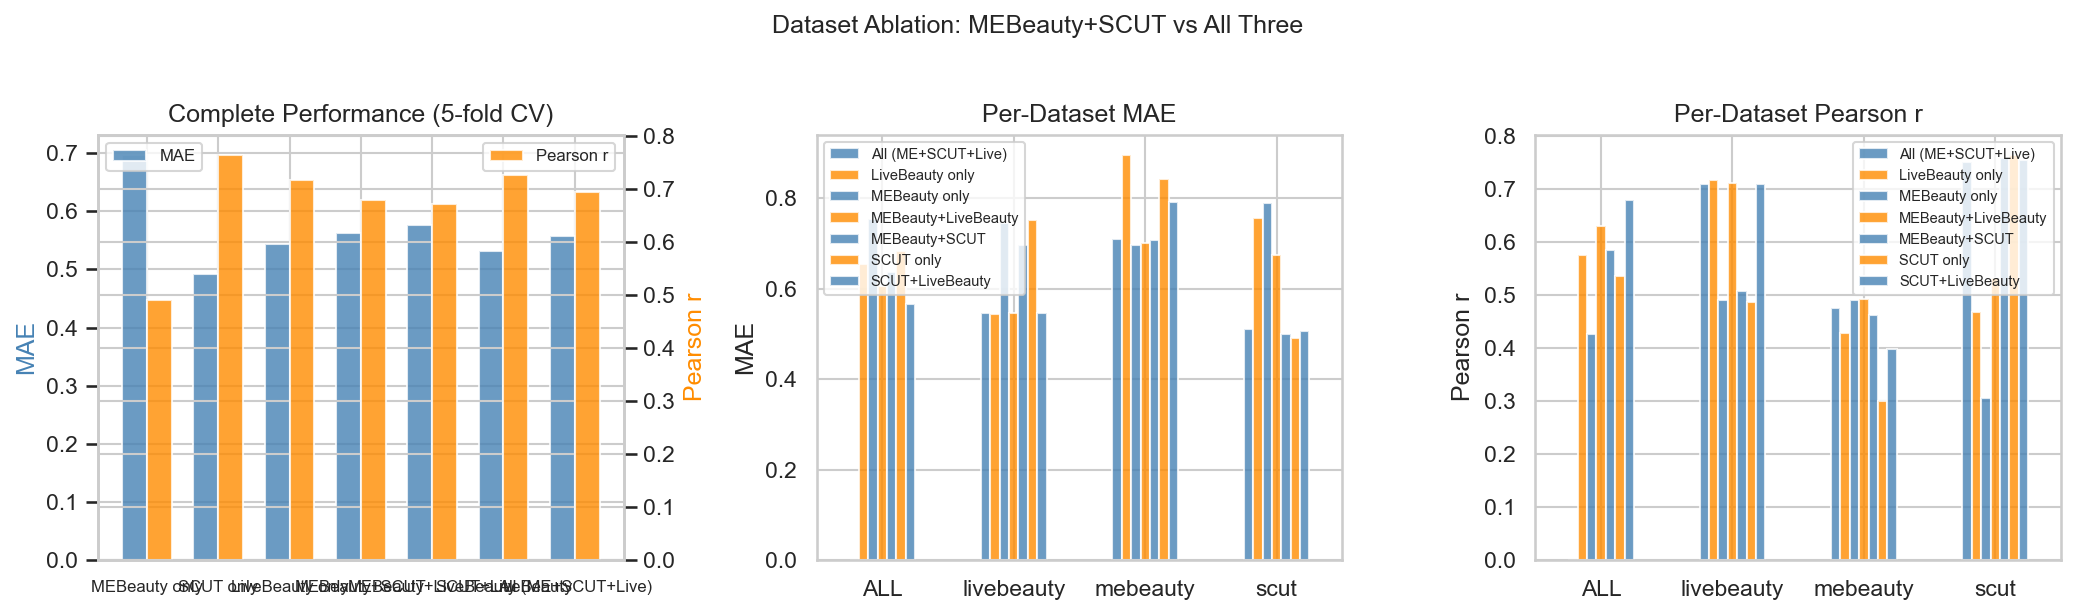

Saved: data/plots/dataset_ablation/ablation_overview.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Plot 1: Complete performance (CV) ---
ax = axes[0]
configs = list(complete_results.keys())
mae_vals = [complete_results[c]["mae"] for c in configs]
r_vals = [complete_results[c]["pearson_r"] for c in configs]

x = np.arange(len(configs))
width = 0.35
bars1 = ax.bar(x - width/2, mae_vals, width, label="MAE", color="steelblue", alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, r_vals, width, label="Pearson r", color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=8)
ax.set_ylabel("MAE", color="steelblue")
ax2.set_ylabel("Pearson r", color="darkorange")
ax.set_title("Complete Performance (5-fold CV)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# --- Plot 2: Per-dataset MAE comparison ---
ax = axes[1]
pivot_mae = per_ds_df.pivot(index="eval_dataset", columns="training_config", values="mae")
pivot_mae.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"], alpha=0.8)
ax.set_ylabel("MAE")
ax.set_title("Per-Dataset MAE")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=7)

# --- Plot 3: Per-dataset Pearson r comparison ---
ax = axes[2]
pivot_r = per_ds_df.pivot(index="eval_dataset", columns="training_config", values="pearson_r")
pivot_r.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"], alpha=0.8)
ax.set_ylabel("Pearson r")
ax.set_title("Per-Dataset Pearson r")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=7)

fig.suptitle("Dataset Ablation: MEBeauty+SCUT vs All Three", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ablation_overview.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'ablation_overview.png'}")

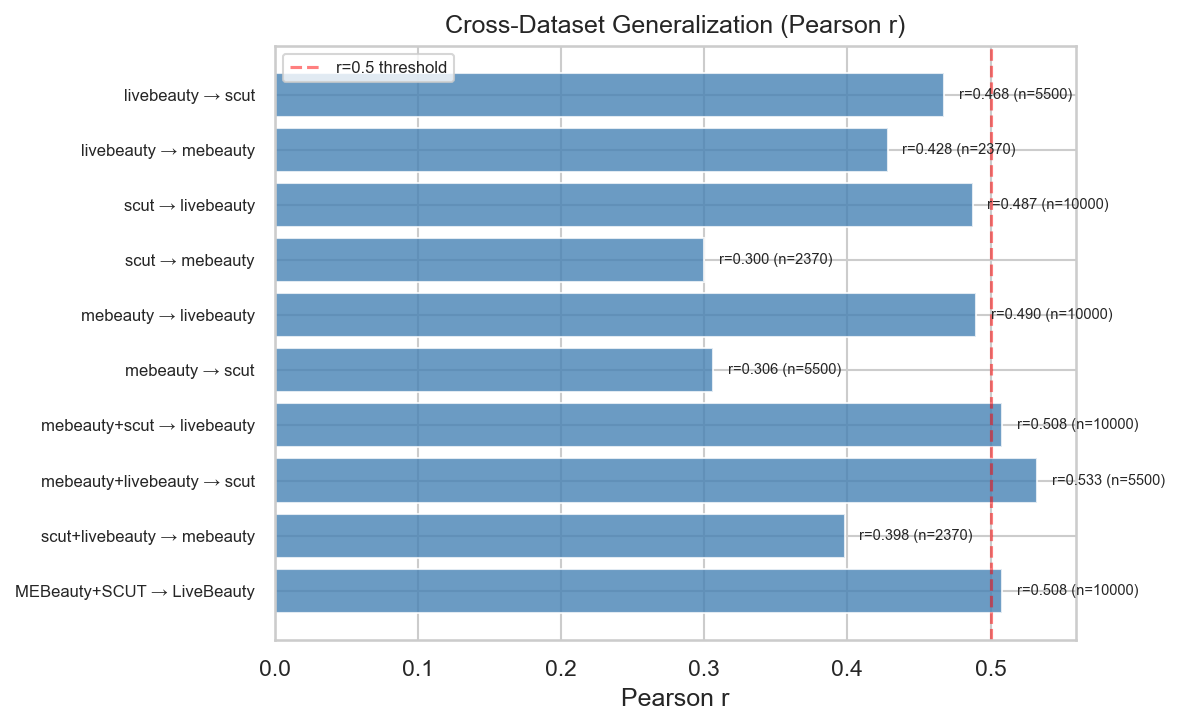

Saved: data/plots/dataset_ablation/cross_dataset_generalization.png


In [10]:
# Cross-dataset generalization heatmap
fig, ax = plt.subplots(figsize=(8, 5))

cross_df_display = cross_df[["experiment", "mae", "pearson_r", "n"]].copy()
cross_df_display = cross_df_display.set_index("experiment")

# Plot as horizontal bar chart for clarity
y_pos = np.arange(len(cross_df_display))
bars = ax.barh(y_pos, cross_df_display["pearson_r"], color="steelblue", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(cross_df_display.index, fontsize=8)
ax.set_xlabel("Pearson r")
ax.set_title("Cross-Dataset Generalization (Pearson r)")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="r=0.5 threshold")
ax.legend(fontsize=8)

for i, (r_val, n) in enumerate(zip(cross_df_display["pearson_r"], cross_df_display["n"])):
    ax.text(r_val + 0.01, i, f"r={r_val:.3f} (n={n})", va="center", fontsize=7)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cross_dataset_generalization.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'cross_dataset_generalization.png'}")

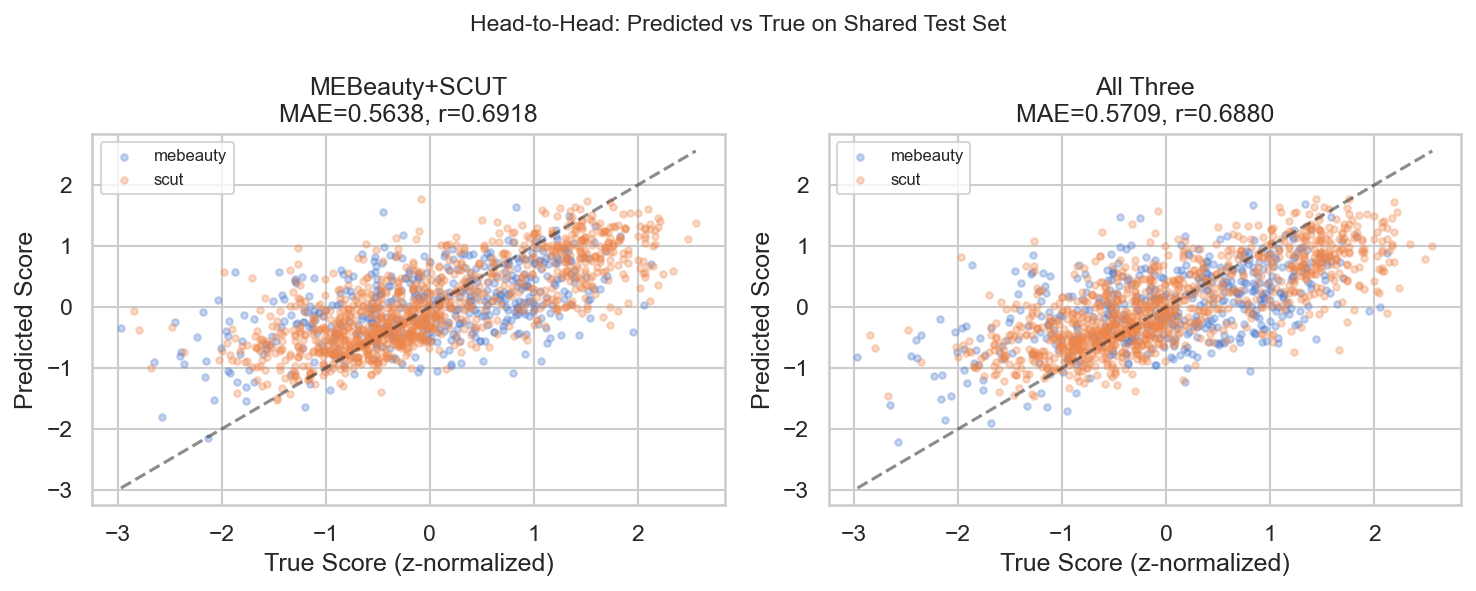

Saved: data/plots/dataset_ablation/head_to_head_scatter.png


In [11]:
# Head-to-head scatter plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in zip(axes, [y_pred_a, y_pred_b], ["MEBeauty+SCUT", "All Three"]):
    for ds in sorted(shared_test["dataset"].unique()):
        mask = datasets_test == ds
        ax.scatter(y_test[mask], y_pred[mask], alpha=0.3, s=10, label=ds)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", alpha=0.5)
    m = compute_metrics(y_test, y_pred)
    ax.set_xlabel("True Score (z-normalized)")
    ax.set_ylabel("Predicted Score")
    ax.set_title(f"{title}\nMAE={m['mae']:.4f}, r={m['pearson_r']:.4f}")
    ax.legend(fontsize=8)

fig.suptitle("Head-to-Head: Predicted vs True on Shared Test Set", fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "head_to_head_scatter.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'head_to_head_scatter.png'}")

## 9. Summary

In [12]:
print("\n" + "="*70)
print("  DATASET ABLATION SUMMARY")
print("="*70)

print("\n  Training Configurations:")
for config_name, config_df in ALL_CONFIGS.items():
    ds_list = sorted(config_df["dataset"].unique())
    print(f"    {config_name:<25s}: {len(config_df):>6d} samples  ({', '.join(ds_list)})")

print("\n  Complete Performance (5-fold CV on own data):")
print(f"    {'Config':<25s} {'MAE':>8s} {'Pearson r':>10s} {'Spearman ρ':>11s}")
print(f"    {'─'*56}")
for config_name, metrics in complete_results.items():
    print(f"    {config_name:<25s} {metrics['mae']:>8.4f} {metrics['pearson_r']:>10.4f} {metrics['spearman_rho']:>11.4f}")

print("\n  Per-Dataset Performance:")
print(f"    {'Config':<22s} {'Dataset':<12s} {'Type':<8s} {'MAE':>6s} {'r':>6s} {'ρ':>6s}")
print(f"    {'─'*65}")
for _, row in per_ds_df.iterrows():
    eval_type_short = "OOF" if "OOF" in row["eval_type"] else "OOD"
    if row["eval_dataset"] == "ALL":
        eval_type_short = "mix"
    print(f"    {row['training_config']:<22s} {row['eval_dataset']:<12s} {eval_type_short:<8s} {row['mae']:>6.4f} {row['pearson_r']:>6.4f} {row['spearman_rho']:>6.4f}")

print("\n  Key Insight: LiveBeauty's near-binary distribution (96% scores are 3 or 4)")
print("  inflates Pearson r and RMSE for any config that includes it. Spearman ρ is")
print("  more robust here — it measures ranking ability regardless of target shape.")

print("\n" + "="*70)
print(f"\n  Plots saved to: {OUTPUT_DIR}/")


  DATASET ABLATION SUMMARY

  Training Configurations:
    MEBeauty only            :   2370 samples  (mebeauty)
    SCUT only                :   5500 samples  (scut)
    LiveBeauty only          :  10000 samples  (livebeauty)
    MEBeauty+SCUT            :   7870 samples  (mebeauty, scut)
    MEBeauty+LiveBeauty      :  12370 samples  (livebeauty, mebeauty)
    SCUT+LiveBeauty          :  15500 samples  (livebeauty, scut)
    All (ME+SCUT+Live)       :  17870 samples  (livebeauty, mebeauty, scut)

  Complete Performance (5-fold CV on own data):
    Config                         MAE  Pearson r  Spearman ρ
    ────────────────────────────────────────────────────────
    MEBeauty only               0.6971     0.4913      0.4614
    SCUT only                   0.4914     0.7647      0.7582
    LiveBeauty only             0.5430     0.7169      0.7324
    MEBeauty+SCUT               0.5627     0.6786      0.6773
    MEBeauty+LiveBeauty         0.5758     0.6714      0.6844
    SCUT+LiveB